In [1]:
!pip install tensorflow==2.15.0
!pip install tensorflow-quantum==0.7.3
!pip install gym==0.18.0
!pip install gym-anytrading
!pip install gym-trading-env pandas-datareader arrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.0
    Uninstalling ml-dtypes-0.4.0:
      Successfully uninstalled ml-dtypes-0.4.0
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1
  Attempting uninstall: tensorboard
    Found existing installation

In [5]:
!pip install cirq

  Using cached cirq_core-1.4.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached cirq_google-1.4.1-py3-none-any.whl.metadata (2.0 kB)
Using cached cirq_core-1.4.1-py3-none-any.whl (1.9 MB)
Using cached cirq_google-1.4.1-py3-none-any.whl (532 kB)
  Attempting uninstall: cirq-core
    Found existing installation: cirq-core 1.3.0
    Uninstalling cirq-core-1.3.0:
      Successfully uninstalled cirq-core-1.3.0
  Attempting uninstall: cirq-google
    Found existing installation: cirq-google 1.3.0
    Uninstalling cirq-google-1.3.0:
      Successfully uninstalled cirq-google-1.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-quantum 0.7.3 requires cirq-core==1.3.0, but you have cirq-core 1.4.1 which is incompatible.
tensorflow-quantum 0.7.3 requires cirq-google==1.3.0, but you have cirq-google 1.4.1 which is incompatible.


##Quantum RL

/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:542: UserWarning: WARN: Overriding environment trading-v0
  logger.warn(f"Overriding environment {spec.id}")
[*********************100%%**********************]  1 of 1 completed
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


/usr/local/lib/python3.10/dist-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/utils/passive_env_checker.py:190: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `return_info` to return information from the environment resetting.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/utils/passive_env_checker.py:141: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/usr

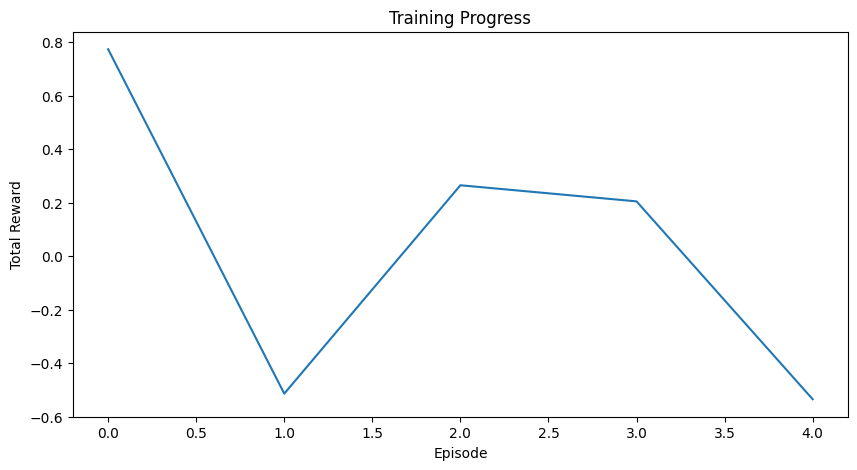

Test Reward: 0.18232251491319446


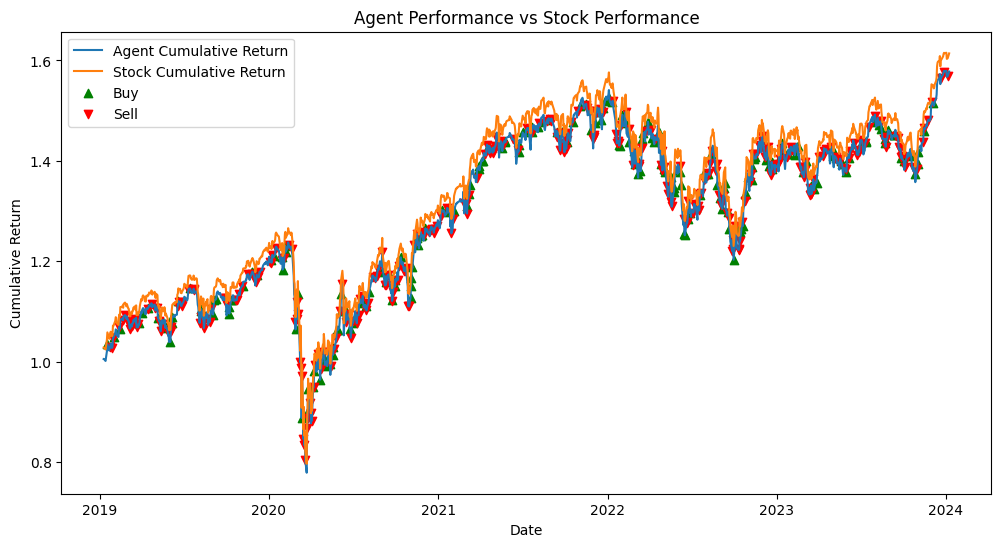

Agent Sharpe Ratio: 0.4962
Stock Sharpe Ratio: 0.4916
Agent Sortino Ratio: 0.7537
Stock Sortino Ratio: 0.7466
Agent Max Drawdown: -0.3709
Stock Max Drawdown: -0.3709


In [4]:
import gym
from gym.envs.registration import register
from gym import spaces
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import random
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq, sympy
from collections import deque
from cirq.contrib.svg import SVGCircuit
from functools import reduce

#Trading Environment
class TradingEnv(gym.Env):
    def __init__(self, start_date, end_date, tc=0.05/100, ticker='^DJI'):
        self.start = start_date
        self.end = end_date
        self.tc = tc
        self.ticker = ticker

        self.action_space = spaces.Discrete(3)  # Buy, Sell, Hold
        self.observation_space = spaces.Box(low=-1, high=1, shape=(5,), dtype=np.float32)
        returns, self.close_prices = self.load_dataset()
        self.data_df = self.create_features(returns)
        self.curr_index = 0
        self.data_len = self.data_df.shape[0]
        self.action = 0

    def step(self, action):
        done = False
        stock_return = self.extract_return(self.data_df, self.curr_index)
        change_in_position = np.abs(self.action - action)
        cost = change_in_position * self.tc
        reward = action * stock_return - cost

        if self.curr_index == self.data_len - 2:
            done = True
        self.curr_index += 1
        self.action = action

        obs = self.extract_state(self.data_df, self.curr_index).values

        info = {'date': self.data_df.index[self.curr_index], 'return': stock_return}

        return obs, reward, done, info

    def reset(self):
        self.curr_index = 0
        self.action = 0
        return self.extract_state(self.data_df, self.curr_index).values

    def render(self, mode='human'):
        pass

    def extract_return(self, df, i):
        return df.iloc[i]['Y']

    def extract_state(self, df, i):
        return df.iloc[i][['r%d' % i for i in range(5)]]

    def load_dataset(self):
        df = yf.download(self.ticker, start=self.start, end=self.end)
        df = df.sort_values(by='Date')
        returns = df['Close'].pct_change()
        return returns, df['Close']

    def create_features(self, returns):
        dfs = []
        for i in range(5):
            dfs.append(returns.shift(i).rename('r%d' % i))
        dfs.append(returns.shift(-1).rename('Y'))
        df_net = pd.concat(dfs, axis=1)
        df_net = df_net.dropna()
        return df_net

    def get_stock_cumulative_return(self):
        cumulative_return = (self.close_prices / self.close_prices.iloc[0])
        return cumulative_return.to_dict()
register(
    id='trading-v0',
    entry_point=__name__ + ':TradingEnv',
    kwargs={
        'start_date': '2019-01-01',
        'end_date': '2024-01-10',
    }
)

def one_qubit_rotation(qubit, symbols):
    return [cirq.rx(symbols[0])(qubit), cirq.ry(symbols[1])(qubit), cirq.rz(symbols[2])(qubit)]

def entangling_layer(qubits):
    cz_ops = [cirq.CZ(q0, q1) for q0, q1 in zip(qubits, qubits[1:])]
    cz_ops += ([cirq.CZ(qubits[0], qubits[-1])] if len(qubits) != 2 else [])
    return cz_ops

def generate_circuit(qubits, n_layers):
    n_qubits = len(qubits)
    params = sympy.symbols(f'theta(0:{3*(n_layers+1)*n_qubits})')
    params = np.asarray(params).reshape((n_layers + 1, n_qubits, 3))
    inputs = sympy.symbols(f'x(0:{n_layers})' + f'_(0:{n_qubits})')
    inputs = np.asarray(inputs).reshape((n_layers, n_qubits))

    circuit = cirq.Circuit()
    for l in range(n_layers):
        circuit += cirq.Circuit(one_qubit_rotation(q, params[l, i]) for i, q in enumerate(qubits))
        circuit += entangling_layer(qubits)
        circuit += cirq.Circuit(cirq.rx(inputs[l, i])(q) for i, q in enumerate(qubits))

    circuit += cirq.Circuit(one_qubit_rotation(q, params[n_layers, i]) for i, q in enumerate(qubits))

    return circuit, list(params.flat), list(inputs.flat)

class ReUploadingPQC(tf.keras.layers.Layer):
    def __init__(self, qubits, n_layers, observables, activation="linear", name="re-uploading_PQC"):
        super(ReUploadingPQC, self).__init__(name=name)
        self.n_layers = n_layers
        self.n_qubits = len(qubits)

        circuit, theta_symbols, input_symbols = generate_circuit(qubits, n_layers)
        SVGCircuit(circuit)
        print(SVGCircuit(circuit))
        theta_init = tf.random_uniform_initializer(minval=0.0, maxval=np.pi)
        self.theta = tf.Variable(
            initial_value=theta_init(shape=(1, len(theta_symbols)), dtype="float32"),
            trainable=True, name="thetas"
        )

        lmbd_init = tf.ones(shape=(self.n_qubits * self.n_layers,))
        self.lmbd = tf.Variable(
            initial_value=lmbd_init, dtype="float32", trainable=True, name="lambdas"
        )

        symbols = [str(symb) for symb in theta_symbols + input_symbols]
        self.indices = tf.constant([symbols.index(a) for a in sorted(symbols)])

        self.activation = activation
        self.empty_circuit = tfq.convert_to_tensor([cirq.Circuit()])
        self.computation_layer = tfq.layers.ControlledPQC(circuit, observables)

    def call(self, inputs):
        batch_dim = tf.gather(tf.shape(inputs[0]), 0)
        tiled_up_circuits = tf.repeat(self.empty_circuit, repeats=batch_dim)
        tiled_up_thetas = tf.tile(self.theta, multiples=[batch_dim, 1])
        tiled_up_inputs = tf.tile(inputs[0], multiples=[1, self.n_layers])
        scaled_inputs = tf.einsum("i,ji->ji", self.lmbd, tiled_up_inputs)
        squashed_inputs = tf.keras.layers.Activation(self.activation)(scaled_inputs)

        joined_vars = tf.concat([tiled_up_thetas, squashed_inputs], axis=1)
        joined_vars = tf.gather(joined_vars, self.indices, axis=1)

        return self.computation_layer([tiled_up_circuits, joined_vars])

class Rescaling(tf.keras.layers.Layer):
    def __init__(self, input_dim):
        super(Rescaling, self).__init__()
        self.input_dim = input_dim
        self.w = tf.Variable(
            initial_value=tf.ones(shape=(1, input_dim)), dtype="float32",
            trainable=True, name="obs-weights")

    def call(self, inputs):
        return tf.math.multiply((inputs + 1) / 2, tf.repeat(self.w, repeats=tf.shape(inputs)[0], axis=0))

def generate_model_Qlearning(qubits, n_layers, n_actions, observables, target):
    input_tensor = tf.keras.Input(shape=(len(qubits),), dtype=tf.dtypes.float32, name='input')
    re_uploading_pqc = ReUploadingPQC(qubits, n_layers, observables, activation='tanh')([input_tensor])
    process = tf.keras.Sequential([Rescaling(len(observables))], name=target * "Target" + "Q-values")
    Q_values = process(re_uploading_pqc)
    model = tf.keras.Model(inputs=[input_tensor], outputs=Q_values)
    return model

class DoubleQuantumAgent:
    def __init__(self, env, qubits, n_layers, observables, learning_rate=0.001, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.n_actions = env.action_space.n

        self.model1 = generate_model_Qlearning(qubits, n_layers, self.n_actions, observables, False)
        self.model2 = generate_model_Qlearning(qubits, n_layers, self.n_actions, observables, False)
        self.target_model1 = generate_model_Qlearning(qubits, n_layers, self.n_actions, observables, True)
        self.target_model2 = generate_model_Qlearning(qubits, n_layers, self.n_actions, observables, True)

        self.optimizer1 = tf.keras.optimizers.Adam(learning_rate=learning_rate, amsgrad=True)
        self.optimizer2 = tf.keras.optimizers.Adam(learning_rate=learning_rate, amsgrad=True)

        # Initialize optimizer variables
        self._initialize_optimizer_variables()

        self.experience_replay = deque(maxlen=1000)

    def _initialize_optimizer_variables(self):
        # Create dummy gradients and variables for both models
        dummy_state = tf.zeros((1, self.env.observation_space.shape[0]))

        # Initialize optimizer variables for model1
        with tf.GradientTape() as tape1:
            dummy_q_values1 = self.model1(dummy_state)
        dummy_gradients1 = tape1.gradient(dummy_q_values1, self.model1.trainable_variables)
        self.optimizer1.apply_gradients(zip(dummy_gradients1, self.model1.trainable_variables))

        # Initialize optimizer variables for model2
        with tf.GradientTape() as tape2:
            dummy_q_values2 = self.model2(dummy_state)
        dummy_gradients2 = tape2.gradient(dummy_q_values2, self.model2.trainable_variables)
        self.optimizer2.apply_gradients(zip(dummy_gradients2, self.model2.trainable_variables))

    def choose_action(self, state):
        if np.random.uniform() < self.epsilon:
            return self.env.action_space.sample()
        else:
            state_tensor = tf.expand_dims(state, axis=0)
            q_values1 = self.model1(state_tensor)
            q_values2 = self.model2(state_tensor)
            q_values = (q_values1 + q_values2) / 2
            return int(tf.argmax(q_values[0]).numpy())

    def update_models(self, batch):
        states = tf.convert_to_tensor([x['state'] for x in batch])
        actions = tf.convert_to_tensor([x['action'] for x in batch])
        rewards = tf.convert_to_tensor([x['reward'] for x in batch], dtype=tf.float32)
        next_states = tf.convert_to_tensor([x['next_state'] for x in batch])
        done = tf.convert_to_tensor([x['done'] for x in batch], dtype=tf.float32)

        # Randomly choose which model to update
        if random.random() < 0.5:
            self.update_model(self.model1, self.target_model2, self.optimizer1, states, actions, rewards, next_states, done)
        else:
            self.update_model(self.model2, self.target_model1, self.optimizer2, states, actions, rewards, next_states, done)

    @tf.function
    def update_model(self, model, target_model, optimizer, states, actions, rewards, next_states, done):
        next_q_values = target_model(next_states)
        max_next_q_values = tf.reduce_max(next_q_values, axis=1)
        target_q_values = rewards + (1 - done) * self.gamma * max_next_q_values

        with tf.GradientTape() as tape:
            q_values = model(states)
            one_hot_actions = tf.one_hot(actions, self.n_actions)
            q_values_for_actions = tf.reduce_sum(tf.multiply(q_values, one_hot_actions), axis=1)
            loss = tf.keras.losses.MSE(target_q_values, q_values_for_actions)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    def update_target_models(self):
        self.target_model1.set_weights(self.model1.get_weights())
        self.target_model2.set_weights(self.model2.get_weights())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

def train_agent(env, agent, n_episodes=5, batch_size=64, steps_per_update=4, steps_per_target_update=100):
    episode_rewards = []
    step_count = 0

    for episode in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = agent.choose_action(state)
            next_state, reward, done, _ = env.step(action)

            agent.experience_replay.append({
                'state': state,
                'action': action,
                'reward': reward,
                'next_state': next_state,
                'done': done
            })

            state = next_state
            total_reward += reward
            step_count += 1
            if len(agent.experience_replay) >= batch_size and step_count % steps_per_update == 0:
                batch = random.sample(agent.experience_replay, batch_size)
                agent.update_models(batch)
            if step_count % steps_per_target_update == 0:
                agent.update_target_models()
        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        if (episode + 1) % 10 == 0:
            avg_reward = np.mean(episode_rewards[-10:])
            print(f"Episode {episode + 1}/{n_episodes}, Avg Reward: {avg_reward:.2f}, Epsilon: {agent.epsilon:.2f}")
    return episode_rewards


def test_agent(env, model):
    state = env.reset()
    done = False
    total_reward = 0
    actions_taken = []
    while not done:
        state_tensor = tf.expand_dims(state, axis=0)
        #q_vals = model([state_tensor])#issue in the calling model instead of agent.model
        q_vals1 = agent.model1([state_tensor])
        q_vals2 = agent.model2([state_tensor])
        q_vals = (q_vals1 + q_vals2) / 2
        action = int(tf.argmax(q_vals[0]).numpy())
        #action = int(tf.argmax(q_vals[0]).numpy())
        next_state, reward, done, info = env.step(action)
        state = next_state
        total_reward += reward
        actions_taken.append((info['date'], action, info.get('position', None), info['return']))
    stock_cumulative_return = env.get_stock_cumulative_return()
    return total_reward, actions_taken, stock_cumulative_return

def calculate_sharpe_ratio(returns, risk_free_rate=0.01):
    excess_returns = returns - risk_free_rate / 252  # Daily risk-free rate
    return np.mean(excess_returns) / np.std(excess_returns) * np.sqrt(252)

def calculate_sortino_ratio(returns, risk_free_rate=0.01):
    excess_returns = returns - risk_free_rate / 252  # Daily risk-free rate
    downside_returns = np.minimum(excess_returns, 0)
    return np.mean(excess_returns) / np.std(downside_returns) * np.sqrt(252)

def calculate_max_drawdown(cumulative_returns):
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns / peak) - 1
    return drawdown.min()


if __name__ == '__main__':
    env = gym.make('trading-v0')
    n_qubits = 5
    n_layers = 5
    qubits = cirq.GridQubit.rect(1, n_qubits)
    ops = [cirq.Z(q) for q in qubits]
    observables = [ops[0]*ops[1], ops[2]*ops[3], ops[4]]

    agent = DoubleQuantumAgent(env, qubits, n_layers, observables)

    #Training
    episode_rewards = train_agent(env, agent)

    #Plot training results
    plt.figure(figsize=(10, 5))
    plt.plot(episode_rewards)
    plt.title('Training Progress')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

    #Testing
    test_reward, actions, stock_cumulative_return = test_agent(env, agent)
    print(f"Test Reward: {test_reward}")


    # Plot test results
    df = pd.DataFrame(actions, columns=['Date', 'Action', 'Position', 'Return'])
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df['AgentCumulativeReturn'] = (1 + df['Return']).cumprod()

    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['AgentCumulativeReturn'], label='Agent Cumulative Return')
    plt.plot(df.index, [stock_cumulative_return[date] for date in df.index], label='Stock Cumulative Return')
    buy_points = df[df['Action'] == 2].index
    sell_points = df[df['Action'] == 0].index
    plt.scatter(buy_points, df.loc[buy_points, 'AgentCumulativeReturn'], color='green', marker='^', label='Buy')
    plt.scatter(sell_points, df.loc[sell_points, 'AgentCumulativeReturn'], color='red', marker='v', label='Sell')
    plt.title('Agent Performance vs Stock Performance')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.show()

    # Calculate risk-adjusted metrics
    agent_returns = df['Return'].values
    stock_returns = np.diff([stock_cumulative_return[date] for date in df.index]) / np.array([stock_cumulative_return[date] for date in df.index][:-1])

    agent_sharpe = calculate_sharpe_ratio(agent_returns)
    stock_sharpe = calculate_sharpe_ratio(stock_returns)

    agent_sortino = calculate_sortino_ratio(agent_returns)
    stock_sortino = calculate_sortino_ratio(stock_returns)

    agent_max_drawdown = calculate_max_drawdown(df['AgentCumulativeReturn'])
    stock_max_drawdown = calculate_max_drawdown(pd.Series(stock_cumulative_return).sort_index())

    print(f"Agent Sharpe Ratio: {agent_sharpe:.4f}")
    print(f"Stock Sharpe Ratio: {stock_sharpe:.4f}")
    print(f"Agent Sortino Ratio: {agent_sortino:.4f}")
    print(f"Stock Sortino Ratio: {stock_sortino:.4f}")
    print(f"Agent Max Drawdown: {agent_max_drawdown:.4f}")
    print(f"Stock Max Drawdown: {stock_max_drawdown:.4f}")

**Reducing to 3 qubits**

In [3]:
import gym
from gym.envs.registration import register
from gym import spaces
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import random
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq, sympy
from collections import deque
from cirq.contrib.svg import SVGCircuit
from functools import reduce


# Trading Environment
class TradingEnv(gym.Env):
    def __init__(self, start_date, end_date, tc=0.05/100, ticker='^DJI'):
        self.start = start_date
        self.end = end_date
        self.tc = tc
        self.ticker = ticker

        self.action_space = spaces.Discrete(3)  # Buy, Sell, Hold
        self.observation_space = spaces.Box(low=-1, high=1, shape=(3,), dtype=np.float32)
        returns = self.load_dataset()
        self.data_df = self.create_features(returns)
        self.curr_index = 0
        self.data_len = self.data_df.shape[0]
        self.action = 0

    def step(self, action):
        done = False
        stock_return = self.extract_return(self.data_df, self.curr_index)
        change_in_position = np.abs(self.action - action)
        cost = change_in_position * self.tc
        reward = action * stock_return - cost

        if self.curr_index == self.data_len - 2:
            done = True
        self.curr_index += 1
        self.action = action

        obs = self.extract_state(self.data_df, self.curr_index).values

        info = {'date': self.data_df.index[self.curr_index], 'return': stock_return}

        return obs, reward, done, info

    def reset(self):
        self.curr_index = 0
        self.action = 0
        return self.extract_state(self.data_df, self.curr_index).values

    def render(self, mode='human'):
        pass

    def extract_return(self, df, i):
        return df.iloc[i]['Y']

    def extract_state(self, df, i):
        return df.iloc[i][['r%d' % i for i in range(3)]]

    def load_dataset(self):
        df = yf.download(self.ticker, start=self.start, end=self.end)
        df = df.sort_values(by='Date')
        returns = df['Close'].pct_change()
        return returns

    def create_features(self, returns):
        dfs = []
        for i in range(3):
            dfs.append(returns.shift(i).rename('r%d' % i))
        dfs.append(returns.shift(-1).rename('Y'))
        df_net = pd.concat(dfs, axis=1)
        df_net = df_net.dropna()
        return df_net

    def get_stock_cumulative_return(self):
        return (self.data_df['Close'] / self.data_df['Close'].iloc[0]).to_dict()

register(
    id='trading-v0',
    entry_point=__name__ + ':TradingEnv',
    kwargs={
        'start_date': '2019-01-01',
        'end_date': '2024-01-10',
    }
)

def one_qubit_rotation(qubit, symbols):
    return [cirq.rx(symbols[0])(qubit), cirq.ry(symbols[1])(qubit), cirq.rz(symbols[2])(qubit)]

def entangling_layer(qubits):
    cz_ops = [cirq.CZ(q0, q1) for q0, q1 in zip(qubits, qubits[1:])]
    cz_ops += ([cirq.CZ(qubits[0], qubits[-1])] if len(qubits) != 2 else [])
    return cz_ops

def generate_circuit(qubits, n_layers):
    n_qubits = len(qubits)
    params = sympy.symbols(f'theta(0:{3*(n_layers+1)*n_qubits})')
    params = np.asarray(params).reshape((n_layers + 1, n_qubits, 3))
    inputs = sympy.symbols(f'x(0:{n_layers})' + f'_(0:{n_qubits})')
    inputs = np.asarray(inputs).reshape((n_layers, n_qubits))

    circuit = cirq.Circuit()
    for l in range(n_layers):
        circuit += cirq.Circuit(one_qubit_rotation(q, params[l, i]) for i, q in enumerate(qubits))
        circuit += entangling_layer(qubits)
        circuit += cirq.Circuit(cirq.rx(inputs[l, i])(q) for i, q in enumerate(qubits))

    circuit += cirq.Circuit(one_qubit_rotation(q, params[n_layers, i]) for i, q in enumerate(qubits))
    SVGCircuit(circuit)
    return circuit, list(params.flat), list(inputs.flat)

class ReUploadingPQC(tf.keras.layers.Layer):
    def __init__(self, qubits, n_layers, observables, activation="linear", name="re-uploading_PQC"):
        super(ReUploadingPQC, self).__init__(name=name)
        self.n_layers = n_layers
        self.n_qubits = len(qubits)

        circuit, theta_symbols, input_symbols = generate_circuit(qubits, n_layers)
        SVGCircuit(circuit)
        theta_init = tf.random_uniform_initializer(minval=0.0, maxval=np.pi)
        self.theta = tf.Variable(
            initial_value=theta_init(shape=(1, len(theta_symbols)), dtype="float32"),
            trainable=True, name="thetas"
        )

        lmbd_init = tf.ones(shape=(self.n_qubits * self.n_layers,))
        self.lmbd = tf.Variable(
            initial_value=lmbd_init, dtype="float32", trainable=True, name="lambdas"
        )

        symbols = [str(symb) for symb in theta_symbols + input_symbols]
        self.indices = tf.constant([symbols.index(a) for a in sorted(symbols)])

        self.activation = activation
        self.empty_circuit = tfq.convert_to_tensor([cirq.Circuit()])
        self.computation_layer = tfq.layers.ControlledPQC(circuit, observables)

    def call(self, inputs):
        batch_dim = tf.gather(tf.shape(inputs[0]), 0)
        tiled_up_circuits = tf.repeat(self.empty_circuit, repeats=batch_dim)
        tiled_up_thetas = tf.tile(self.theta, multiples=[batch_dim, 1])
        tiled_up_inputs = tf.tile(inputs[0], multiples=[1, self.n_layers])
        scaled_inputs = tf.einsum("i,ji->ji", self.lmbd, tiled_up_inputs)
        squashed_inputs = tf.keras.layers.Activation(self.activation)(scaled_inputs)

        joined_vars = tf.concat([tiled_up_thetas, squashed_inputs], axis=1)
        joined_vars = tf.gather(joined_vars, self.indices, axis=1)

        return self.computation_layer([tiled_up_circuits, joined_vars])

class Rescaling(tf.keras.layers.Layer):
    def __init__(self, input_dim):
        super(Rescaling, self).__init__()
        self.input_dim = input_dim
        self.w = tf.Variable(
            initial_value=tf.ones(shape=(1, input_dim)), dtype="float32",
            trainable=True, name="obs-weights")

    def call(self, inputs):
        return tf.math.multiply((inputs + 1) / 2, tf.repeat(self.w, repeats=tf.shape(inputs)[0], axis=0))

def generate_model_Qlearning(qubits, n_layers, n_actions, observables, target):
    input_tensor = tf.keras.Input(shape=(len(qubits),), dtype=tf.dtypes.float32, name='input')
    re_uploading_pqc = ReUploadingPQC(qubits, n_layers, observables, activation='tanh')([input_tensor])
    process = tf.keras.Sequential([
        Rescaling(len(observables)),
        tf.keras.layers.Dense(n_actions, activation='linear')
    ], name=target * "Target" + "Q-values")
    Q_values = process(re_uploading_pqc)
    model = tf.keras.Model(inputs=[input_tensor], outputs=Q_values)
    return model



class DoubleQuantumAgent:
    def __init__(self, env, qubits, n_layers, observables, learning_rate=0.001, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.n_actions = env.action_space.n

        self.model1 = generate_model_Qlearning(qubits, n_layers, self.n_actions, observables, False)
        self.model2 = generate_model_Qlearning(qubits, n_layers, self.n_actions, observables, False)
        self.target_model1 = generate_model_Qlearning(qubits, n_layers, self.n_actions, observables, True)
        self.target_model2 = generate_model_Qlearning(qubits, n_layers, self.n_actions, observables, True)

        self.optimizer1 = tf.keras.optimizers.Adam(learning_rate=learning_rate, amsgrad=True)
        self.optimizer2 = tf.keras.optimizers.Adam(learning_rate=learning_rate, amsgrad=True)

        # Initialize optimizer variables
        self._initialize_optimizer_variables()

        self.experience_replay = deque(maxlen=1000)

    def _initialize_optimizer_variables(self):
        # Create dummy gradients and variables for both models
        dummy_state = tf.zeros((1, self.env.observation_space.shape[0]))

        # Initialize optimizer variables for model1
        with tf.GradientTape() as tape1:
            dummy_q_values1 = self.model1(dummy_state)
        dummy_gradients1 = tape1.gradient(dummy_q_values1, self.model1.trainable_variables)
        self.optimizer1.apply_gradients(zip(dummy_gradients1, self.model1.trainable_variables))

        # Initialize optimizer variables for model2
        with tf.GradientTape() as tape2:
            dummy_q_values2 = self.model2(dummy_state)
        dummy_gradients2 = tape2.gradient(dummy_q_values2, self.model2.trainable_variables)
        self.optimizer2.apply_gradients(zip(dummy_gradients2, self.model2.trainable_variables))

    def choose_action(self, state):
        if np.random.uniform() < self.epsilon:
            return self.env.action_space.sample()
        else:
            state_tensor = tf.expand_dims(state, axis=0)
            q_values1 = self.model1(state_tensor)
            q_values2 = self.model2(state_tensor)
            q_values = (q_values1 + q_values2) / 2
            return int(tf.argmax(q_values[0]).numpy())

    def update_models(self, batch):
        states = tf.convert_to_tensor([x['state'] for x in batch])
        actions = tf.convert_to_tensor([x['action'] for x in batch])
        rewards = tf.convert_to_tensor([x['reward'] for x in batch], dtype=tf.float32)
        next_states = tf.convert_to_tensor([x['next_state'] for x in batch])
        done = tf.convert_to_tensor([x['done'] for x in batch], dtype=tf.float32)

        # Randomly choose which model to update
        if random.random() < 0.5:
            self.update_model(self.model1, self.target_model2, self.optimizer1, states, actions, rewards, next_states, done)
        else:
            self.update_model(self.model2, self.target_model1, self.optimizer2, states, actions, rewards, next_states, done)

    @tf.function
    def update_model(self, model, target_model, optimizer, states, actions, rewards, next_states, done):
        next_q_values = target_model(next_states)
        max_next_q_values = tf.reduce_max(next_q_values, axis=1)
        target_q_values = rewards + (1 - done) * self.gamma * max_next_q_values

        with tf.GradientTape() as tape:
            q_values = model(states)
            one_hot_actions = tf.one_hot(actions, self.n_actions)
            q_values_for_actions = tf.reduce_sum(tf.multiply(q_values, one_hot_actions), axis=1)
            loss = tf.keras.losses.MSE(target_q_values, q_values_for_actions)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    def update_target_models(self):
        self.target_model1.set_weights(self.model1.get_weights())
        self.target_model2.set_weights(self.model2.get_weights())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

def train_agent(env, agent, n_episodes=2, batch_size=64, steps_per_update=4, steps_per_target_update=100):
    episode_rewards = []
    step_count = 0

    for episode in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = agent.choose_action(state)
            next_state, reward, done, _ = env.step(action)

            agent.experience_replay.append({
                'state': state,
                'action': action,
                'reward': reward,
                'next_state': next_state,
                'done': done
            })

            state = next_state
            total_reward += reward
            step_count += 1

            if len(agent.experience_replay) >= batch_size and step_count % steps_per_update == 0:
                batch = random.sample(agent.experience_replay, batch_size)
                agent.update_models(batch)

            if step_count % steps_per_target_update == 0:
                agent.update_target_models()

        agent.decay_epsilon()
        episode_rewards.append(total_reward)

        if (episode + 1) % 10 == 0:
            avg_reward = np.mean(episode_rewards[-10:])
            print(f"Episode {episode + 1}/{n_episodes}, Avg Reward: {avg_reward:.2f}, Epsilon: {agent.epsilon:.2f}")

    return episode_rewards


def test_agent(env, model):
    state = env.reset()
    done = False
    total_reward = 0
    actions_taken = []
    while not done:
        state_tensor = tf.expand_dims(state, axis=0)
        q_vals = agent.model([state_tensor])
        action = int(tf.argmax(q_vals[0]).numpy())
        next_state, reward, done, info = env.step(action)
        state = next_state
        total_reward += reward
        actions_taken.append((info['date'], action, info.get('position', None), info['return']))
    stock_cumulative_return = env.get_stock_cumulative_return()
    return total_reward, actions_taken, stock_cumulative_return

def calculate_sharpe_ratio(returns, risk_free_rate=0.01):
    excess_returns = returns - risk_free_rate / 252  # Daily risk-free rate
    return np.mean(excess_returns) / np.std(excess_returns) * np.sqrt(252)

def calculate_sortino_ratio(returns, risk_free_rate=0.01):
    excess_returns = returns - risk_free_rate / 252  # Daily risk-free rate
    downside_returns = np.minimum(excess_returns, 0)
    return np.mean(excess_returns) / np.std(downside_returns) * np.sqrt(252)

def calculate_max_drawdown(cumulative_returns):
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns / peak) - 1
    return drawdown.min()


if __name__ == '__main__':
    env = gym.make('trading-v0')

    n_qubits = 3
    n_layers = 5
    qubits = cirq.GridQubit.rect(1, n_qubits)
    ops = [cirq.Z(q) for q in qubits]
    observables = [ops[0], ops[1], ops[2]]  #3 qubits

    agent = DoubleQuantumAgent(env, qubits, n_layers, observables)

    #Training
    episode_rewards = train_agent(env, agent)

    #Plot training results
    plt.figure(figsize=(10, 5))
    plt.plot(episode_rewards)
    plt.title('Training Progress')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

    #Testing
    test_reward, actions, stock_cumulative_return = test_agent(env, agent)
    print(f"Test Reward: {test_reward}")


    # Plot test results
    df = pd.DataFrame(actions, columns=['Date', 'Action', 'Position', 'Return'])
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df['AgentCumulativeReturn'] = (1 + df['Return']).cumprod()

    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['AgentCumulativeReturn'], label='Agent Cumulative Return')
    plt.plot(df.index, [stock_cumulative_return[date] for date in df.index], label='Stock Cumulative Return')
    buy_points = df[df['Action'] == 2].index
    sell_points = df[df['Action'] == 0].index
    plt.scatter(buy_points, df.loc[buy_points, 'AgentCumulativeReturn'], color='green', marker='^', label='Buy')
    plt.scatter(sell_points, df.loc[sell_points, 'AgentCumulativeReturn'], color='red', marker='v', label='Sell')
    plt.title('Agent Performance vs Stock Performance')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.show()

    # Calculate risk-adjusted metrics
    agent_returns = df['Return'].values
    stock_returns = np.diff([stock_cumulative_return[date] for date in df.index]) / np.array([stock_cumulative_return[date] for date in df.index][:-1])

    agent_sharpe = calculate_sharpe_ratio(agent_returns)
    stock_sharpe = calculate_sharpe_ratio(stock_returns)

    agent_sortino = calculate_sortino_ratio(agent_returns)
    stock_sortino = calculate_sortino_ratio(stock_returns)

    agent_max_drawdown = calculate_max_drawdown(df['AgentCumulativeReturn'])
    stock_max_drawdown = calculate_max_drawdown(pd.Series(stock_cumulative_return).sort_index())

    print(f"Agent Sharpe Ratio: {agent_sharpe:.4f}")
    print(f"Stock Sharpe Ratio: {stock_sharpe:.4f}")
    print(f"Agent Sortino Ratio: {agent_sortino:.4f}")
    print(f"Stock Sortino Ratio: {stock_sortino:.4f}")
    print(f"Agent Max Drawdown: {agent_max_drawdown:.4f}")
    print(f"Stock Max Drawdown: {stock_max_drawdown:.4f}")



[*********************100%%**********************]  1 of 1 completed
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


KeyboardInterrupt: 